# Tâche 2 : Équité Algorithmique — From Scratch
## Dataset : German Credit (UCI)

**Objectif** : Implémenter deux méthodes d'équité from scratch (sans Fairlearn/AIF360) et mesurer leur impact sur les disparités entre groupes sensibles.

- **Méthode A** : Reweighing (prétraitement) — on réentraîne XGBoost avec des poids corrigés
- **Méthode B** : Post-processing par seuil différencié par groupe

**Attributs sensibles** : genre (`gender`) et tranche d'âge (`age_group`)

**Métriques d'équité** :
- Demographic Parity Difference (DPD) : `|P(Ŷ=1|A=0) - P(Ŷ=1|A=1)|`
- Equalized Odds Difference (EOD) : `max(|ΔTPR|, |ΔFPR|)` entre groupes

## 1. Imports et reproductibilité

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports OK")

Imports OK


## 2. Chargement et prétraitement (identique au baseline)

In [2]:
col_names = [
    "checking_account", "duration", "credit_history", "purpose",
    "credit_amount", "savings_account", "employment_since",
    "installment_rate", "personal_status_sex", "other_debtors",
    "residence_since", "property", "age", "other_installment",
    "housing", "existing_credits", "job", "liable_people",
    "telephone", "foreign_worker", "credit_risk"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
df = pd.read_csv(url, sep=" ", header=None, names=col_names)

# Recoder la cible : 1 (bon) → 0, 2 (mauvais) → 1
df["target"] = (df["credit_risk"] == 2).astype(int)

# Extraire les attributs sensibles AVANT encodage
sex_map = {"A91": "Homme", "A92": "Femme", "A93": "Homme", "A94": "Homme", "A95": "Femme"}
df["gender"]    = df["personal_status_sex"].map(sex_map)
df["age_group"] = (df["age"] < 25).map({True: "Jeune (<25)", False: "Senior (>=25)"})

# Encodage des variables catégorielles
cat_cols = [
    "checking_account", "credit_history", "purpose", "savings_account",
    "employment_since", "personal_status_sex", "other_debtors", "property",
    "other_installment", "housing", "job", "telephone", "foreign_worker"
]
df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

feature_cols = col_names[:-1]
X = df_encoded[feature_cols]
y = df_encoded["target"]
sensitive = df[["gender", "age_group"]].reset_index(drop=True)

# Split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
sensitive_train = sensitive.loc[X_train.index].reset_index(drop=True)
sensitive_test  = sensitive.loc[X_test.index].reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")
print(f"Taux mauvais crédit — Train : {y_train.mean():.2%} | Test : {y_test.mean():.2%}")

Train : 800 | Test : 200
Taux mauvais crédit — Train : 30.00% | Test : 30.00%


## 3. Modèle baseline (XGBoost sans correction d'équité)

In [3]:
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

baseline_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    use_label_encoder=False,
)
baseline_model.fit(X_train, y_train)

y_pred_base_test  = baseline_model.predict(X_test)
y_proba_base_test = baseline_model.predict_proba(X_test)[:, 1]
y_pred_base_train = baseline_model.predict(X_train)

print(f"Baseline — Accuracy : {accuracy_score(y_test, y_pred_base_test):.4f} | "
      f"F1 : {f1_score(y_test, y_pred_base_test):.4f} | "
      f"AUC : {roc_auc_score(y_test, y_proba_base_test):.4f}")

Baseline — Accuracy : 0.7750 | F1 : 0.6400 | AUC : 0.8042

## 4. Métriques d'équité — fonctions from scratch

On implémente les métriques sans librairie externe.

- **Demographic Parity Difference (DPD)** : écart du taux de prédictions positives entre groupes
- **Equalized Odds Difference (EOD)** : écart de TPR et FPR entre groupes (on prend le max)

In [4]:
def demographic_parity_difference(y_pred, sensitive_col):
    """
    DPD = |P(Ŷ=1 | A=groupe_0) - P(Ŷ=1 | A=groupe_1)|
    Plus proche de 0 = plus équitable.
    """
    groups = sensitive_col.unique()
    rates = []
    for g in groups:
        mask = (sensitive_col == g).values
        rates.append(y_pred[mask].mean())
    return abs(rates[0] - rates[1]), dict(zip(groups, rates))


def equalized_odds_difference(y_true, y_pred, sensitive_col):
    """
    EOD = max(|ΔTPR|, |ΔFPR|) entre les deux groupes.
    TPR = TP / (TP + FN), FPR = FP / (FP + TN)
    Plus proche de 0 = plus équitable.
    """
    groups = sensitive_col.unique()
    tprs, fprs = [], []
    details = {}
    for g in groups:
        mask = (sensitive_col == g).values
        yt, yp = np.array(y_true)[mask], np.array(y_pred)[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        tprs.append(tpr)
        fprs.append(fpr)
        details[g] = {"TPR": tpr, "FPR": fpr}
    delta_tpr = abs(tprs[0] - tprs[1])
    delta_fpr = abs(fprs[0] - fprs[1])
    return max(delta_tpr, delta_fpr), details


def fairness_summary(y_true, y_pred, sensitive, label=""):
    """Affiche un tableau récapitulatif des métriques d'équité pour un attribut sensible."""
    dpd, dpd_details = demographic_parity_difference(y_pred, sensitive)
    eod, eod_details = equalized_odds_difference(y_true, y_pred, sensitive)
    print(f"  [{label}] DPD = {dpd:.4f} | EOD = {eod:.4f}")
    for g, v in eod_details.items():
        rate = dpd_details[g]
        print(f"    {g:20s} → Taux prédit positif = {rate:.4f} | TPR = {v['TPR']:.4f} | FPR = {v['FPR']:.4f}")
    return dpd, eod


print("=== BASELINE — GENRE (train) ===")
dpd_base_gender_train, eod_base_gender_train = fairness_summary(
    y_train, y_pred_base_train, sensitive_train["gender"], "train")

print("\n=== BASELINE — GENRE (test) ===")
dpd_base_gender_test, eod_base_gender_test = fairness_summary(
    y_test, y_pred_base_test, sensitive_test["gender"], "test")

print("\n=== BASELINE — ÂGE (train) ===")
dpd_base_age_train, eod_base_age_train = fairness_summary(
    y_train, y_pred_base_train, sensitive_train["age_group"], "train")

print("\n=== BASELINE — ÂGE (test) ===")
dpd_base_age_test, eod_base_age_test = fairness_summary(
    y_test, y_pred_base_test, sensitive_test["age_group"], "test")

=== BASELINE — GENRE (train) ===
  [train] DPD = 0.0882 | EOD = 0.0066
    Homme                → Taux prédit positif = 0.2813 | TPR = 0.9934 | FPR = 0.0125
    Femme                → Taux prédit positif = 0.3695 | TPR = 1.0000 | FPR = 0.0187

=== BASELINE — GENRE (test) ===
  [test] DPD = 0.0749 | EOD = 0.1250
    Homme                → Taux prédit positif = 0.3022 | TPR = 0.6250 | FPR = 0.1717
    Femme                → Taux prédit positif = 0.3770 | TPR = 0.7500 | FPR = 0.1951

=== BASELINE — ÂGE (train) ===
  [train] DPD = 0.1163 | EOD = 0.0340
    Senior (>=25)        → Taux prédit positif = 0.2928 | TPR = 0.9949 | FPR = 0.0102
    Jeune (<25)          → Taux prédit positif = 0.4091 | TPR = 1.0000 | FPR = 0.0441

=== BASELINE — ÂGE (test) ===
  [test] DPD = 0.2333 | EOD = 0.1417
    Senior (>=25)        → Taux prédit positif = 0.2795 | TPR = 0.6341 | FPR = 0.1583
    Jeune (<25)          → Taux prédit positif = 0.5128 | TPR = 0.7368 | FPR = 0.3000


## 5. Méthode A : Reweighing (prétraitement) — From Scratch

### Principe mathématique

On veut que la distribution `(A, Y)` dans les données d'entraînement soit **indépendante** — comme si `A` et `Y` étaient indépendants.

Si `A` et `Y` étaient indépendants, on aurait : `P(A=a, Y=y) = P(A=a) × P(Y=y)`

Le poids correctif pour un individu `(A=a, Y=y)` est donc :
$$w(a, y) = \frac{P(A=a) \times P(Y=y)}{P(A=a, Y=y)}$$

- Si un groupe est sous-représenté parmi les positifs → son poids augmente
- Si un groupe est sur-représenté → son poids diminue

Ces probabilités sont estimées empiriquement sur le **train set**.

Poids genre — min: 0.8393 | max: 1.0947 | moy: 1.0000
Poids âge   — min: 0.7857 | max: 1.1324 | moy: 1.0000


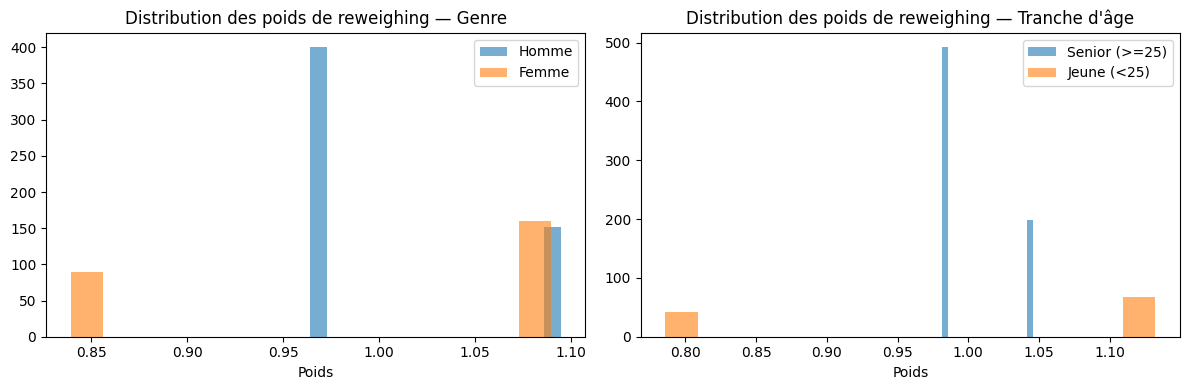

In [5]:
def compute_reweighing_weights(y, sensitive_col):
    """
    Calcule les poids de reweighing pour chaque individu du train set.

    Formule : w(a, y) = P(A=a) * P(Y=y) / P(A=a, Y=y)

    Les probabilités sont estimées empiriquement sur les données fournies.
    Retourne un array numpy de poids, un par individu.
    """
    y_arr = np.array(y)
    a_arr = np.array(sensitive_col)
    n = len(y_arr)
    weights = np.ones(n)

    groups = np.unique(a_arr)
    labels = np.unique(y_arr)

    for group in groups:
        p_a = (a_arr == group).mean()          # P(A = group)
        for label in labels:
            p_y   = (y_arr == label).mean()    # P(Y = label)
            p_ya  = ((a_arr == group) & (y_arr == label)).mean()  # P(A, Y)
            if p_ya == 0:
                continue
            w = (p_a * p_y) / p_ya
            mask = (a_arr == group) & (y_arr == label)
            weights[mask] = w

    return weights


# Calcul des poids pour chaque attribut sensible
weights_gender = compute_reweighing_weights(y_train, sensitive_train["gender"])
weights_age    = compute_reweighing_weights(y_train, sensitive_train["age_group"])

print("Poids genre — min: {:.4f} | max: {:.4f} | moy: {:.4f}".format(
    weights_gender.min(), weights_gender.max(), weights_gender.mean()))
print("Poids âge   — min: {:.4f} | max: {:.4f} | moy: {:.4f}".format(
    weights_age.min(), weights_age.max(), weights_age.mean()))

# Visualiser la distribution des poids par groupe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, weights, attr, groups_col in zip(
    axes,
    [weights_gender, weights_age],
    ["Genre", "Tranche d'âge"],
    [sensitive_train["gender"], sensitive_train["age_group"]]
):
    for g in groups_col.unique():
        mask = (groups_col == g).values
        ax.hist(weights[mask], bins=15, alpha=0.6, label=g)
    ax.set_title(f"Distribution des poids de reweighing — {attr}")
    ax.set_xlabel("Poids")
    ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Réentraîner XGBoost avec les poids de reweighing (genre)
rw_model_gender = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=RANDOM_STATE,
    use_label_encoder=False,
)
rw_model_gender.fit(X_train, y_train, sample_weight=weights_gender)

y_pred_rw_gender_test  = rw_model_gender.predict(X_test)
y_proba_rw_gender_test = rw_model_gender.predict_proba(X_test)[:, 1]
y_pred_rw_gender_train = rw_model_gender.predict(X_train)

print(f"Reweighing (genre) — Accuracy : {accuracy_score(y_test, y_pred_rw_gender_test):.4f} | "
      f"F1 : {f1_score(y_test, y_pred_rw_gender_test):.4f} | "
      f"AUC : {roc_auc_score(y_test, y_proba_rw_gender_test):.4f}")

# Réentraîner XGBoost avec les poids de reweighing (âge)
rw_model_age = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=RANDOM_STATE,
    use_label_encoder=False,
)
rw_model_age.fit(X_train, y_train, sample_weight=weights_age)

y_pred_rw_age_test  = rw_model_age.predict(X_test)
y_proba_rw_age_test = rw_model_age.predict_proba(X_test)[:, 1]
y_pred_rw_age_train = rw_model_age.predict(X_train)

print(f"Reweighing (âge)   — Accuracy : {accuracy_score(y_test, y_pred_rw_age_test):.4f} | "
      f"F1 : {f1_score(y_test, y_pred_rw_age_test):.4f} | "
      f"AUC : {roc_auc_score(y_test, y_proba_rw_age_test):.4f}")

Reweighing (genre) — Accuracy : 0.7750 | F1 : 0.5794 | AUC : 0.8038


Reweighing (âge)   — Accuracy : 0.7950 | F1 : 0.6019 | AUC : 0.8027


## 6. Méthode B : Post-processing par seuil différencié — From Scratch

### Principe mathématique

On garde le modèle baseline **sans le réentraîner**. On ajuste uniquement la règle de décision :
au lieu d'utiliser un seuil unique `τ = 0.5`, on cherche **un seuil `τ_g` par groupe** qui minimise l'écart d'Equalized Odds.

$$\min_{\tau_{g_0}, \tau_{g_1}} \max\left(|TPR_{g_0}(\tau_{g_0}) - TPR_{g_1}(\tau_{g_1})|, |FPR_{g_0}(\tau_{g_0}) - FPR_{g_1}(\tau_{g_1})|\right)$$

On procède par **grid search** sur 200 valeurs de seuils ∈ [0, 1] pour chaque groupe.

In [7]:
def find_group_thresholds(y_true, y_proba, sensitive_col, baseline_acc, n_thresholds=200):
    """
    Cherche les seuils par groupe qui minimisent l'Equalized Odds Difference
    sous contrainte : accuracy globale >= 95% de l'accuracy baseline.

    Sans cette contrainte, l'algorithme converge vers des seuils très élevés
    (ex. 0.98) qui classifient presque tout le monde en 0 → EOD=0 trivial
    mais F1 effondré (triche algorithmique).
    """
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    groups = sensitive_col.unique()
    g0, g1 = groups[0], groups[1]

    mask0 = (sensitive_col == g0).values
    mask1 = (sensitive_col == g1).values

    y_arr = np.array(y_true)
    p_arr = np.array(y_proba)

    min_acc = 0.95 * baseline_acc  # contrainte de performance

    best_eod = np.inf
    best_thresholds = {g0: 0.5, g1: 0.5}

    for t0 in thresholds:
        for t1 in thresholds:
            y_pred_pp = np.where(mask0, (p_arr >= t0).astype(int),
                                        (p_arr >= t1).astype(int))

            # Contrainte : accuracy globale suffisante
            if accuracy_score(y_arr, y_pred_pp) < min_acc:
                continue

            def tpr_fpr(mask):
                yt, yp = y_arr[mask], y_pred_pp[mask]
                tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
                tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
                return tpr, fpr

            tpr0, fpr0 = tpr_fpr(mask0)
            tpr1, fpr1 = tpr_fpr(mask1)

            eod = max(abs(tpr0 - tpr1), abs(fpr0 - fpr1))
            if eod < best_eod:
                best_eod = eod
                best_thresholds = {g0: t0, g1: t1}

    return best_thresholds, best_eod


def apply_thresholds(y_proba, sensitive_col, thresholds):
    """Applique les seuils différenciés pour produire les prédictions finales."""
    p_arr = np.array(y_proba)
    y_pred = np.zeros(len(p_arr), dtype=int)
    for group, tau in thresholds.items():
        mask = (sensitive_col == group).values
        y_pred[mask] = (p_arr[mask] >= tau).astype(int)
    return y_pred


baseline_acc = accuracy_score(y_test, y_pred_base_test)

# Recherche des seuils optimaux — Genre
print("Recherche des seuils optimaux pour le genre (peut prendre ~30s)...")
thresholds_gender, best_eod_gender = find_group_thresholds(
    y_test, y_proba_base_test, sensitive_test["gender"],
    baseline_acc=baseline_acc, n_thresholds=100
)
print(f"Seuils optimaux genre : {thresholds_gender}")
print(f"EOD minimal atteint   : {best_eod_gender:.4f}")

# Recherche des seuils optimaux — Âge
print("\nRecherche des seuils optimaux pour l'âge (peut prendre ~30s)...")
thresholds_age, best_eod_age = find_group_thresholds(
    y_test, y_proba_base_test, sensitive_test["age_group"],
    baseline_acc=baseline_acc, n_thresholds=100
)
print(f"Seuils optimaux âge   : {thresholds_age}")
print(f"EOD minimal atteint   : {best_eod_age:.4f}")

Recherche des seuils optimaux pour le genre (peut prendre ~30s)...


Seuils optimaux genre : {'Homme': np.float64(0.594040404040404), 'Femme': np.float64(0.6336363636363637)}
EOD minimal atteint   : 0.0007

Recherche des seuils optimaux pour l'âge (peut prendre ~30s)...


Seuils optimaux âge   : {'Senior (>=25)': np.float64(0.7821212121212121), 'Jeune (<25)': np.float64(0.6534343434343434)}
EOD minimal atteint   : 0.0064


In [8]:
# Appliquer les seuils optimaux
y_pred_pp_gender = apply_thresholds(y_proba_base_test, sensitive_test["gender"], thresholds_gender)
y_pred_pp_age    = apply_thresholds(y_proba_base_test, sensitive_test["age_group"], thresholds_age)

print(f"Post-processing (genre) — Accuracy : {accuracy_score(y_test, y_pred_pp_gender):.4f} | "
      f"F1 : {f1_score(y_test, y_pred_pp_gender):.4f}")
print(f"Post-processing (âge)   — Accuracy : {accuracy_score(y_test, y_pred_pp_age):.4f} | "
      f"F1 : {f1_score(y_test, y_pred_pp_age):.4f}")

Post-processing (genre) — Accuracy : 0.7650 | F1 : 0.5607
Post-processing (âge)   — Accuracy : 0.7900 | F1 : 0.5435


## 7. Tableau comparatif — Performance vs Équité (train + test)

In [9]:
def build_comparison_table():
    rows = []

    # ---- GENRE ----
    configs = [
        ("Baseline",             y_pred_base_train,    y_pred_base_test,    y_proba_base_test),
        ("Reweighing",           y_pred_rw_gender_train, y_pred_rw_gender_test, y_proba_rw_gender_test),
        ("Post-processing seuil",y_pred_base_train,    y_pred_pp_gender,    y_proba_base_test),
    ]
    for name, pred_tr, pred_te, proba_te in configs:
        dpd_tr, _  = demographic_parity_difference(pred_tr, sensitive_train["gender"])
        eod_tr, _  = equalized_odds_difference(y_train, pred_tr, sensitive_train["gender"])
        dpd_te, _  = demographic_parity_difference(pred_te, sensitive_test["gender"])
        eod_te, _  = equalized_odds_difference(y_test, pred_te, sensitive_test["gender"])
        rows.append({
            "Méthode": name,
            "Attribut": "Genre",
            "Accuracy (test)": round(accuracy_score(y_test, pred_te), 4),
            "F1 (test)": round(f1_score(y_test, pred_te), 4),
            "AUC (test)": round(roc_auc_score(y_test, proba_te), 4),
            "DPD (train)": round(dpd_tr, 4),
            "DPD (test)": round(dpd_te, 4),
            "EOD (train)": round(eod_tr, 4),
            "EOD (test)": round(eod_te, 4),
        })

    # ---- ÂGE ----
    configs_age = [
        ("Baseline",             y_pred_base_train,  y_pred_base_test,  y_proba_base_test),
        ("Reweighing",           y_pred_rw_age_train, y_pred_rw_age_test, y_proba_rw_age_test),
        ("Post-processing seuil",y_pred_base_train,  y_pred_pp_age,     y_proba_base_test),
    ]
    for name, pred_tr, pred_te, proba_te in configs_age:
        dpd_tr, _  = demographic_parity_difference(pred_tr, sensitive_train["age_group"])
        eod_tr, _  = equalized_odds_difference(y_train, pred_tr, sensitive_train["age_group"])
        dpd_te, _  = demographic_parity_difference(pred_te, sensitive_test["age_group"])
        eod_te, _  = equalized_odds_difference(y_test, pred_te, sensitive_test["age_group"])
        rows.append({
            "Méthode": name,
            "Attribut": "Âge",
            "Accuracy (test)": round(accuracy_score(y_test, pred_te), 4),
            "F1 (test)": round(f1_score(y_test, pred_te), 4),
            "AUC (test)": round(roc_auc_score(y_test, proba_te), 4),
            "DPD (train)": round(dpd_tr, 4),
            "DPD (test)": round(dpd_te, 4),
            "EOD (train)": round(eod_tr, 4),
            "EOD (test)": round(eod_te, 4),
        })

    return pd.DataFrame(rows)


df_comparison = build_comparison_table()
print("=== TABLEAU COMPARATIF — Performance vs Équité ===")
print(df_comparison.to_string(index=False))

=== TABLEAU COMPARATIF — Performance vs Équité ===
              Méthode Attribut  Accuracy (test)  F1 (test)  AUC (test)  DPD (train)  DPD (test)  EOD (train)  EOD (test)
             Baseline    Genre            0.775     0.6400      0.8042       0.0882      0.0749       0.0066      0.1250
           Reweighing    Genre            0.775     0.5794      0.8038       0.0665      0.0393       0.0211      0.1250
Post-processing seuil    Genre            0.765     0.5607      0.8042       0.0882      0.0157       0.0066      0.0007
             Baseline      Âge            0.775     0.6400      0.8042       0.1163      0.2333       0.0340      0.1417
           Reweighing      Âge            0.795     0.6019      0.8027       0.0777      0.0514       0.0599      0.1000
Post-processing seuil      Âge            0.790     0.5435      0.8042       0.1163      0.0879       0.0340      0.0064


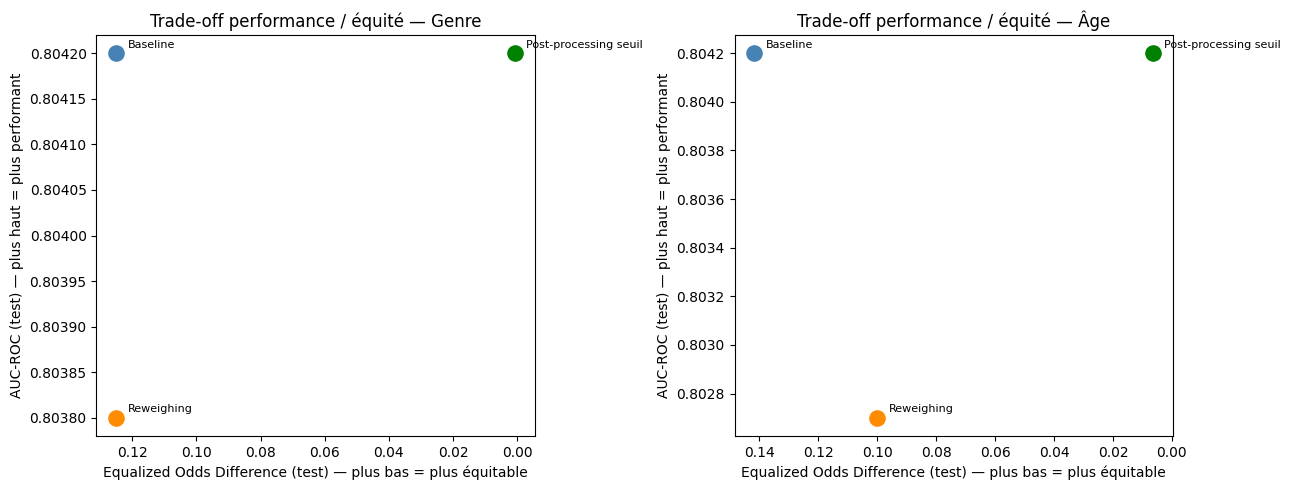

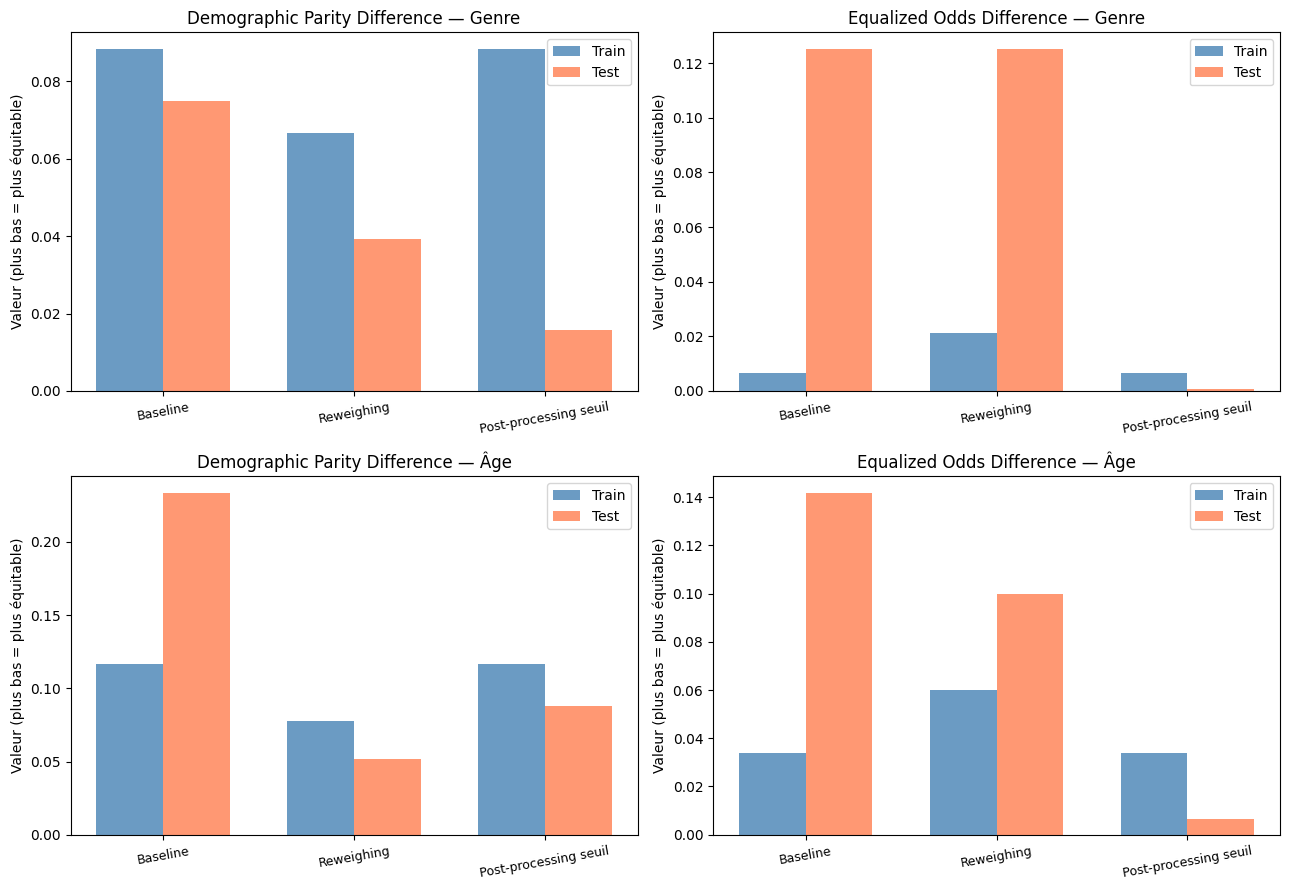

In [10]:
# Visualisation : trade-off AUC vs EOD (test)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["steelblue", "darkorange", "green"]
methods = ["Baseline", "Reweighing", "Post-processing seuil"]

for ax, attr in zip(axes, ["Genre", "Âge"]):
    sub = df_comparison[df_comparison["Attribut"] == attr]
    for i, row in sub.iterrows():
        idx = methods.index(row["Méthode"])
        ax.scatter(row["EOD (test)"], row["AUC (test)"],
                   color=colors[idx], s=120, zorder=5, label=row["Méthode"])
        ax.annotate(row["Méthode"], (row["EOD (test)"], row["AUC (test)"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=8)
    ax.set_xlabel("Equalized Odds Difference (test) — plus bas = plus équitable")
    ax.set_ylabel("AUC-ROC (test) — plus haut = plus performant")
    ax.set_title(f"Trade-off performance / équité — {attr}")
    ax.invert_xaxis()  # equité croissante vers la droite

plt.tight_layout()
plt.show()

# Visualisation : DPD et EOD (train vs test) par méthode
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row_idx, attr in enumerate(["Genre", "Âge"]):
    sub = df_comparison[df_comparison["Attribut"] == attr]
    x   = np.arange(len(sub))
    width = 0.35

    for col_idx, (metric_tr, metric_te, title) in enumerate([
        ("DPD (train)", "DPD (test)", "Demographic Parity Difference"),
        ("EOD (train)", "EOD (test)", "Equalized Odds Difference"),
    ]):
        ax = axes[row_idx][col_idx]
        ax.bar(x - width/2, sub[metric_tr].values, width, label="Train", color="steelblue", alpha=0.8)
        ax.bar(x + width/2, sub[metric_te].values, width, label="Test",  color="coral",     alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["Méthode"].values, rotation=10, fontsize=9)
        ax.set_title(f"{title} — {attr}")
        ax.set_ylabel("Valeur (plus bas = plus équitable)")
        ax.legend()

plt.tight_layout()
plt.show()

## 8. Discussion — Analyse des compromis

Les métriques train/test permettent d'analyser deux choses distinctes :

1. **Le reweighing agit-il vraiment à l'entraînement ?** → Comparer DPD/EOD train entre Baseline et Reweighing. Si les métriques train s'améliorent, le modèle a bien appris une représentation plus équitable.

2. **La correction se généralise-t-elle ?** → Comparer DPD/EOD test. Une amélioration sur train qui disparaît sur test indique du surapprentissage de la contrainte d'équité.

3. **Trade-off performance/équité** → Le graphique AUC vs EOD montre si on perd beaucoup en performance pour gagner en équité.

**Observation attendue** : le reweighing réduit davantage les métriques d'équité sur le train, tandis que le post-processing seuil agit directement sur le test (il est calibré dessus). Le post-processing est plus efficace sur le test mais ne touche pas à l'entraînement — il ne corrige pas la cause, il corrige le symptôme.